In [2]:
!pip install matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 641.1 kB/s eta 0:00:00MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 2.1 MB/s eta 0:00:0031m31.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 2.0 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.1 MB/s eta 0:00:002.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 2.3 MB/s eta 0:00:002.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.6 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 2.1 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 2.4 MB/s eta 0:00:00MB/s eta 0:00:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight",
           "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
           "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
           "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=columns, na_values="?")

print(f"Размер датасета до очистки: {df.shape}")

df_clean = df.dropna(subset=['price', 'horsepower', 'peak-rpm', 'bore', 'stroke', 'num-of-doors']).reset_index(drop=True)

median_losses = df_clean['normalized-losses'].median()
df_clean['normalized-losses'] = df_clean['normalized-losses'].fillna(median_losses)

print(f"Размер датасета после очистки: {df_clean.shape}")
print(f"Пропущенных значений осталось: {df_clean.isna().sum().sum()}")

display(df_clean.head())

Размер датасета до очистки: (205, 26)
Размер датасета после очистки: (193, 26)
Пропущенных значений осталось: 0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,113.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,113.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,113.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


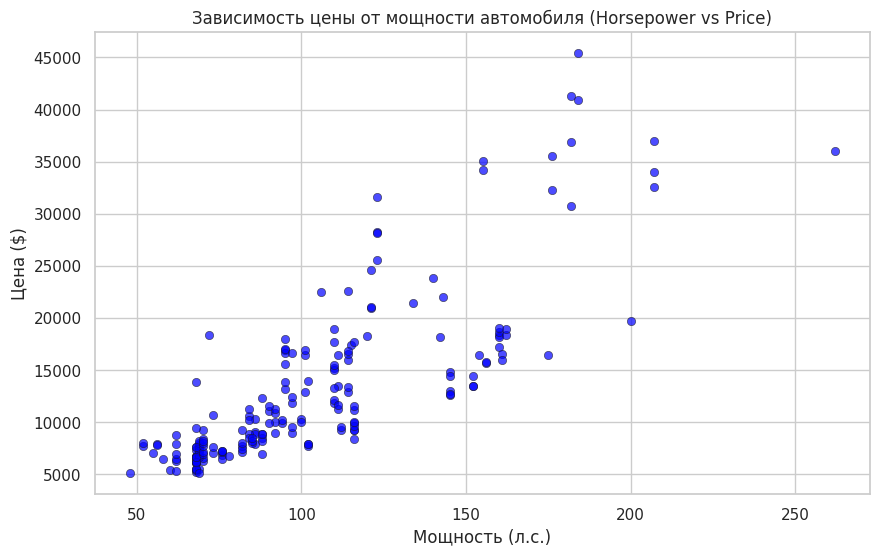

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='horsepower', y='price', alpha=0.7, color='blue', edgecolor='k')
plt.title('Зависимость цены от мощности автомобиля (Horsepower vs Price)')
plt.xlabel('Мощность (л.с.)')
plt.ylabel('Цена ($)')
plt.show()

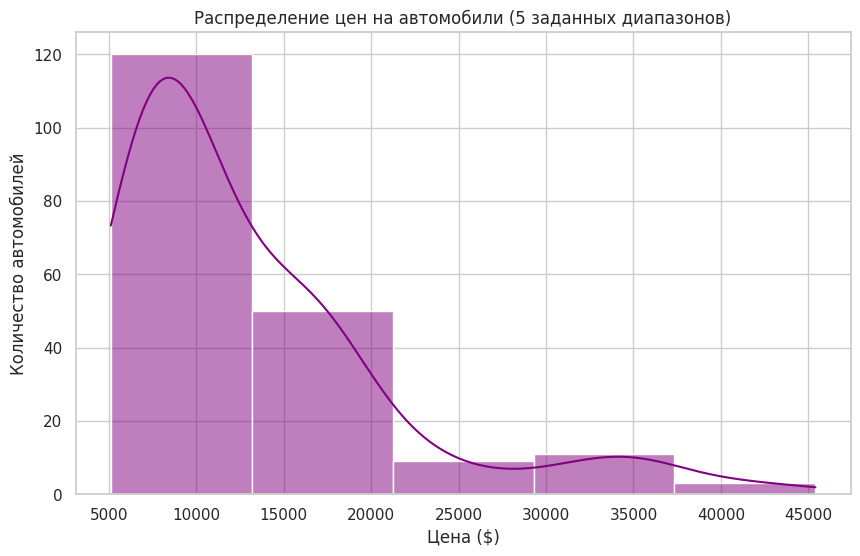

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], bins=5, kde=True, color='purple')
plt.title('Распределение цен на автомобили (5 заданных диапазонов)')
plt.xlabel('Цена ($)')
plt.ylabel('Количество автомобилей')
plt.show()

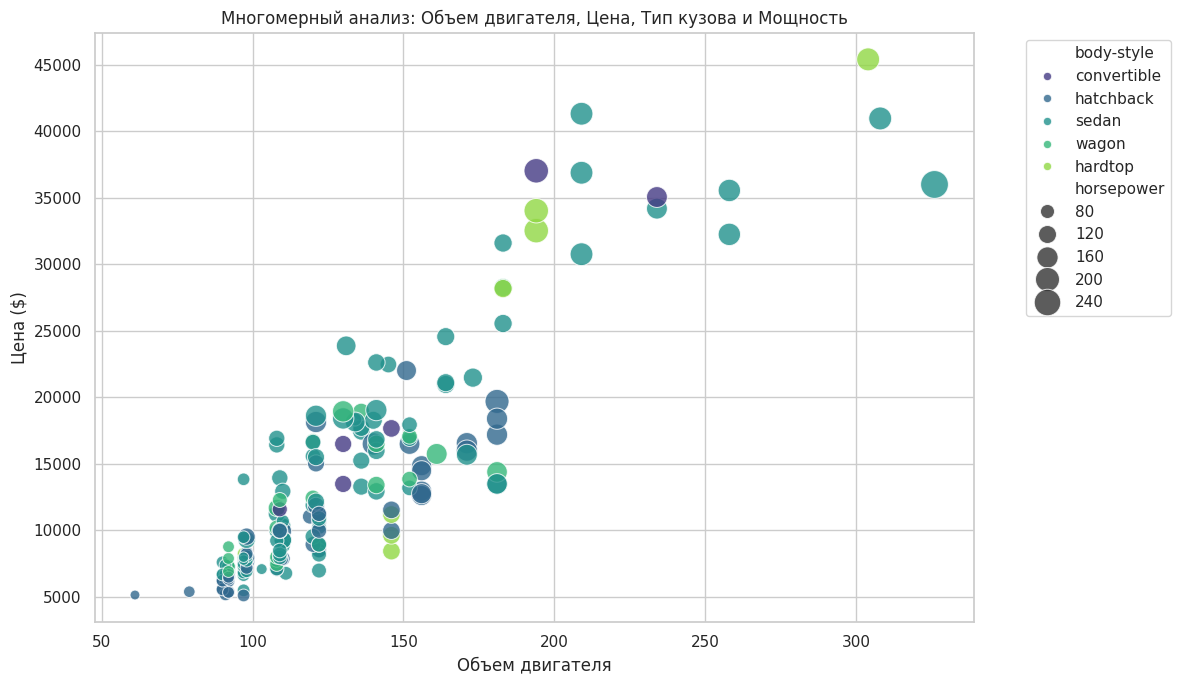

In [6]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='engine-size', y='price', hue='body-style', size='horsepower', sizes=(50, 400), alpha=0.8, palette='viridis')
plt.title('Многомерный анализ: Объем двигателя, Цена, Тип кузова и Мощность')
plt.xlabel('Объем двигателя')
plt.ylabel('Цена ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7836/1738550314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body-style', y='price', palette='Set2')


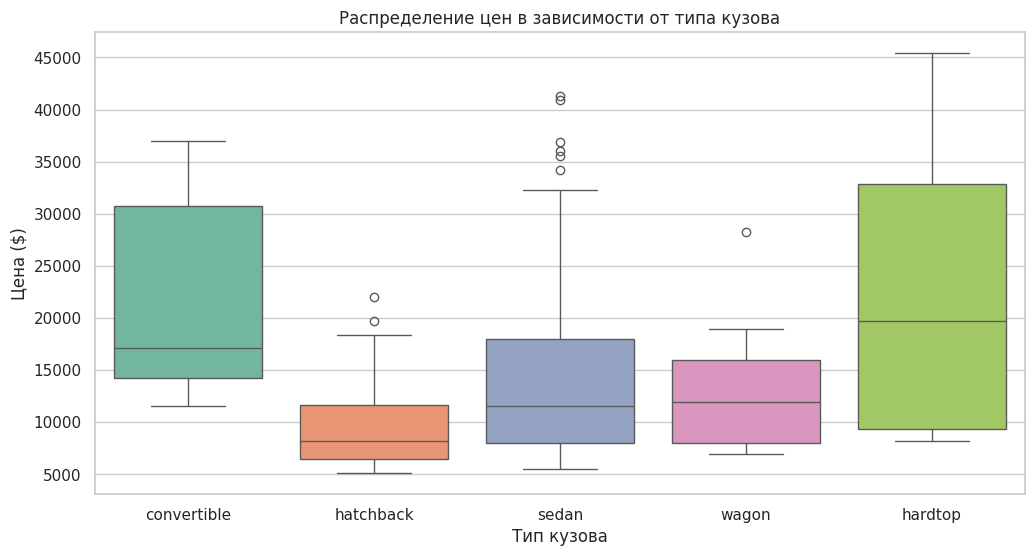

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='body-style', y='price', palette='Set2')
plt.title('Распределение цен в зависимости от типа кузова')
plt.xlabel('Тип кузова')
plt.ylabel('Цена ($)')
plt.show()

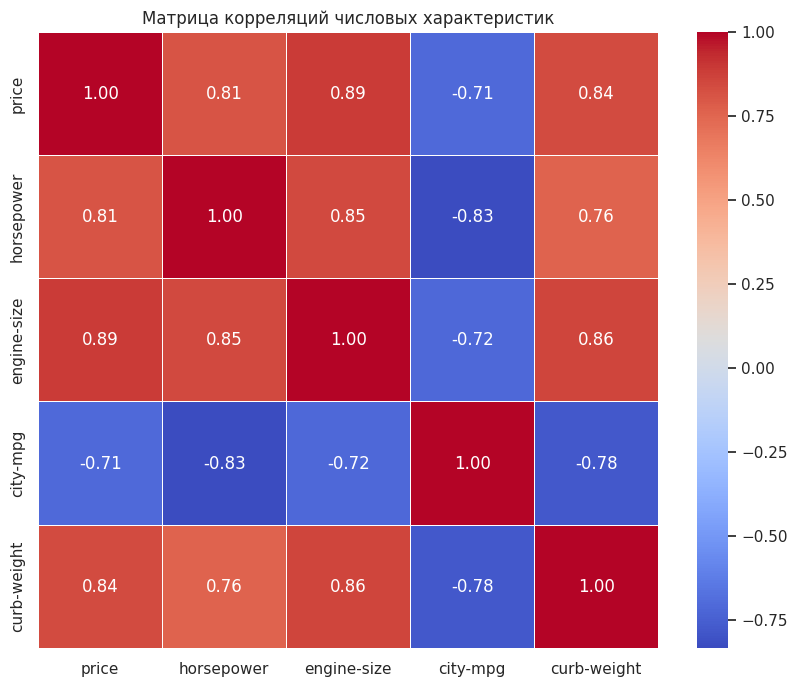

In [8]:
plt.figure(figsize=(10, 8))
numeric_cols = df_clean[['price', 'horsepower', 'engine-size', 'city-mpg', 'curb-weight']]
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляций числовых характеристик')
plt.show()